In [ ]:
import json

import pandas as pd
import geopandas
import matplotlib.pyplot as plt
import seaborn as sns
from shapely import wkt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from utils import CATEGORIAS_TIPO_CHAMADOS

In [2]:
FIG_PATH = "../results/figures/"
RJ_CENTER = [-22.934727, -43.446687]

## Carrega dados

In [3]:
df = geopandas.read_file("../data/bairro.csv")
df['geometry'] = df['geometry'].apply(wkt.loads)
bairros = geopandas.GeoDataFrame(df, crs="EPSG:4326")
bairros = bairros.set_index("id_bairro")


df = geopandas.read_file("../data/area_planejamento.csv")
df['geometry'] = df['geometry'].apply(wkt.loads)
area_planejamento = geopandas.GeoDataFrame(df, crs="EPSG:4326")
area_planejamento = area_planejamento.set_index("id_area_planejamento")


df = geopandas.read_file("../data/regiao_administrativa.csv")
df['geometry'] = df['geometry'].apply(wkt.loads)
regiao_administrativa = geopandas.GeoDataFrame(df, crs="EPSG:4326")
regiao_administrativa = regiao_administrativa.set_index("id_regiao_administrativa")


df = geopandas.read_file("../data/subprefeitura.csv")
df['geometry'] = df['geometria'].apply(wkt.loads)
subprefeitura = geopandas.GeoDataFrame(df, crs="EPSG:4326")

meteo_dfs = {}
for id_bairro in bairros.index:
    meteo_dfs[id_bairro] = pd.read_csv(f"../data/meteo/{id_bairro}.csv", index_col=0)

df_chamados = pd.read_csv("../data/chamados_1746.csv")

feriados = pd.read_csv("../data/feriados.csv")

censo2022 = pd.read_csv("../data/censo2022_habitantes_bairros.csv")

with open('../data/meteo/wmo.json') as f:
    wmo_mapper = json.load(f)

In [4]:
df_chamados["data_inicio"] = pd.to_datetime(df_chamados["data_inicio"])
df_chamados["data_fim"] = pd.to_datetime(df_chamados["data_fim"])

df_chamados["tempo_solucao"] = (df_chamados["data_fim"] - df_chamados["data_inicio"])

df_chamados["tempo_solucao_horas"] = df_chamados["tempo_solucao"].dt.total_seconds() / 3600
df_chamados["tempo_solucao_dias"] = df_chamados["tempo_solucao_horas"] / 24

df_chamados["resolvido_antes_7_dias"] = df_chamados["tempo_solucao_dias"] < 7

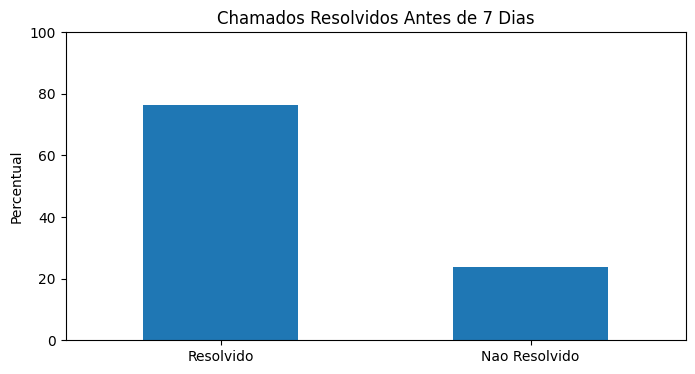

In [5]:
(df_chamados["resolvido_antes_7_dias"].value_counts()*100 / len(df_chamados)).plot(
    kind="bar",
    figsize=(8, 4),
    title="Chamados Resolvidos Antes de 7 Dias",
)
plt.ylabel("Percentual")
plt.xlabel("")
plt.xticks(ticks=[0, 1], labels=["Resolvido", "Nao Resolvido"], rotation=0)
plt.ylim(0, 100)
plt.show()

In [6]:
df_chamados["tipo_chamado"] = df_chamados["tipo"].apply(
    lambda x: next((categoria for categoria, tipos in CATEGORIAS_TIPO_CHAMADOS.items() if x in tipos), "Outros / Diversos"))

Text(0, 0.5, 'Reclamações')

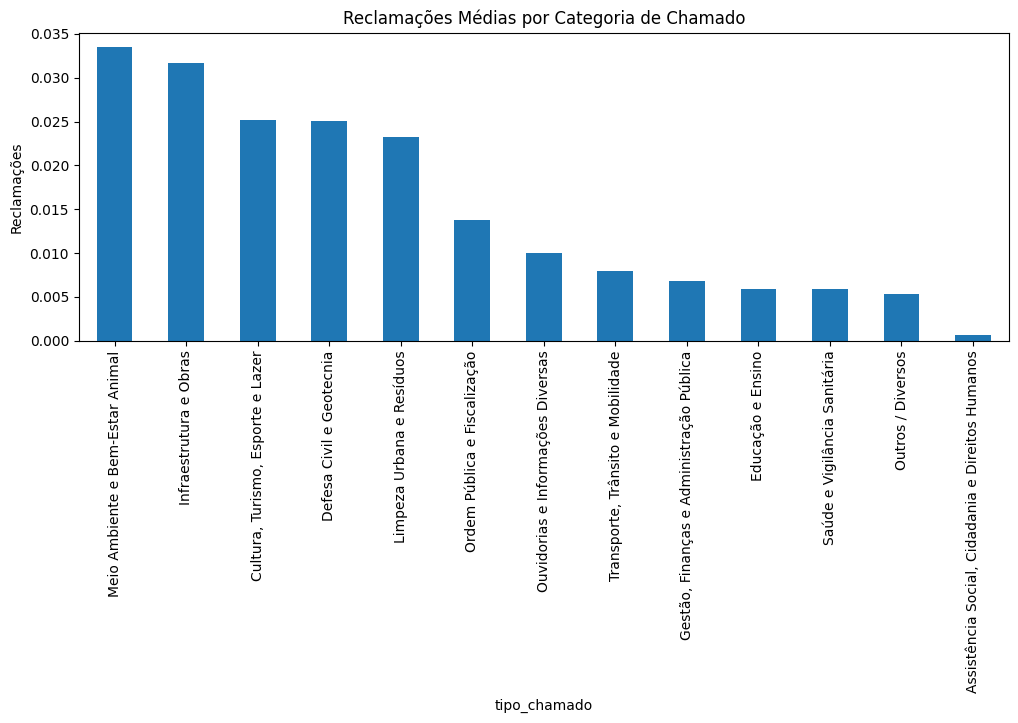

In [7]:
df_chamados.groupby("tipo_chamado")["reclamacoes"].mean().sort_values(ascending=False).plot(
    kind="bar", 
    figsize=(12, 4), 
    title="Reclamações Médias por Categoria de Chamado"
    )
plt.ylabel("Reclamações")

Text(0, 0.5, 'Dias')

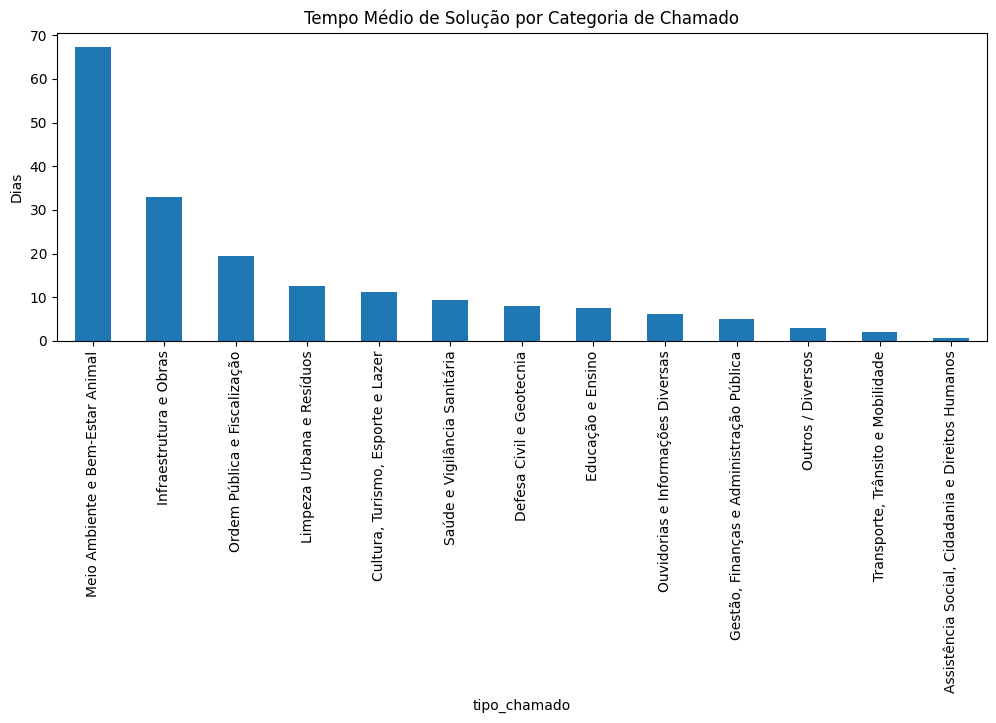

In [8]:
df_chamados.groupby("tipo_chamado")["tempo_solucao_dias"].mean().sort_values(ascending=False).plot(
    kind="bar", 
    figsize=(12, 4), 
    title="Tempo Médio de Solução por Categoria de Chamado"
    )
plt.ylabel("Dias")

In [9]:
df_chamados["id_bairro"] = df_chamados["id_bairro"].astype(str)
df_chamados["id_bairro"] = df_chamados["id_bairro"].str.rstrip(".0")

for id_bairro in meteo_dfs.keys():
    meteo_dfs[id_bairro]["id_bairro"] = id_bairro
meteo_dfs = pd.concat(meteo_dfs).reset_index(drop=True)
meteo_dfs["daily.weather_code"] = meteo_dfs["daily.weather_code"].apply(lambda x: wmo_mapper.get(str(x), "Unknown")["day"]["description"])

In [10]:
meteo_dfs["Tempo Intenso"] = 0
meteo_dfs.loc[meteo_dfs["daily.weather_code"].str.contains("Thunderstorm"), "Tempo Intenso"] = 1
meteo_dfs.loc[meteo_dfs["daily.temperature_2m_max"] > meteo_dfs["daily.temperature_2m_max"].quantile(0.9), "Tempo Intenso"] = 1
meteo_dfs.loc[meteo_dfs["daily.temperature_2m_min"] < meteo_dfs["daily.temperature_2m_min"].quantile(0.1), "Tempo Intenso"] = 1

In [11]:
weather_cols = [
    "id_bairro", 
    "daily.time", 
    "daily.temperature_2m_max", 
    "daily.temperature_2m_min", 
    "daily.wind_speed_10m_max", 
    "daily.precipitation_sum", 
    "daily.uv_index_max", 
    "Tempo Intenso"]

df = pd.merge(
    left=df_chamados,
    right=meteo_dfs[weather_cols],
    left_on=["id_bairro", "data_particao"],
    right_on=["id_bairro", "daily.time"],
    how="left"
)

weather_cols_mapper = {
    "daily.time": "Dia de Abertura do Chamado",
    "daily.temperature_2m_max": "Temperatura Maxima", 
    "daily.temperature_2m_min": "Temperatura Minima", 
    "daily.wind_speed_10m_max": "Vento Maximo", 
    "daily.precipitation_sum": "Precipitacao Maxima", 
    "daily.uv_index_max": "Indice UV Maximo"
}

df = df.rename(columns=weather_cols_mapper)
df["Dia de Abertura do Chamado"] = df_chamados["data_inicio"].dt.date

In [12]:
mapper = df.groupby(["Dia de Abertura do Chamado"]).agg({
    "Temperatura Maxima": "mean", 
    "Temperatura Minima": "mean", 
    "Vento Maximo": "mean", 
    "Precipitacao Maxima": "mean", 
    "Indice UV Maximo": "mean", 
    "Tempo Intenso": "max"
})

In [13]:
pd.DataFrame.from_dict(df["Dia de Abertura do Chamado"].map(mapper.to_dict('index')))

,Dia de Abertura do Chamado
0,"{'Temperatura Maxima': 23.836210018105007, 'Te..."
1,"{'Temperatura Maxima': 29.02750157331655, 'Tem..."
2,"{'Temperatura Maxima': 25.510878417684697, 'Te..."
3,"{'Temperatura Maxima': 29.02750157331655, 'Tem..."
4,"{'Temperatura Maxima': 25.807980922098572, 'Te..."
...,...
2792441,"{'Temperatura Maxima': 32.32746478873239, 'Tem..."
2792442,"{'Temperatura Maxima': 32.988440472758725, 'Te..."
2792443,"{'Temperatura Maxima': 27.952994505494505, 'Te..."
2792444,"{'Temperatura Maxima': 27.952994505494505, 'Te..."


In [ ]:
sampled_df = df.sample(n=50000)
sampled_df = pd.get_dummies(sampled_df, columns=["tipo_chamado"])

In [22]:
features = ["Temperatura Maxima", "Temperatura Minima", "Vento Maximo", "Precipitacao Maxima", "Indice UV Maximo", "Tempo Intenso"]
tipo_chamado_cols = [col for col in sampled_df.columns if col.startswith("tipo_chamado_")]
features.extend(tipo_chamado_cols)

In [ ]:
df_train = sampled_df[sampled_df["data_inicio"].dt.year == 2023]
df_test = sampled_df[sampled_df["data_inicio"].dt.year == 2024]

x_train = df_train[features]
x_test = df_test[features]

y_train = df_train["resolvido_antes_7_dias"]
y_test = df_test["resolvido_antes_7_dias"]

# Preenchendo com a média por simplicidade, mas idealmente deveria fazer o merge usando a média do dia do chamado
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_test.mean())

Baseline

In [89]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.46      0.10      0.17      5965
        True       0.78      0.96      0.86     19962

    accuracy                           0.77     25927
   macro avg       0.62      0.53      0.52     25927
weighted avg       0.71      0.77      0.70     25927



<Axes: >

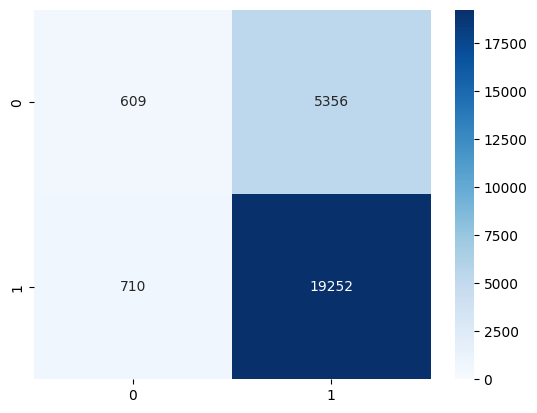

In [ ]:
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True,
    vmin=0,
    cmap="Blues",
    fmt="d")

Random Forest

In [115]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.41      0.21      0.28      5965
        True       0.79      0.91      0.85     19962

    accuracy                           0.75     25927
   macro avg       0.60      0.56      0.56     25927
weighted avg       0.71      0.75      0.72     25927



<Axes: >

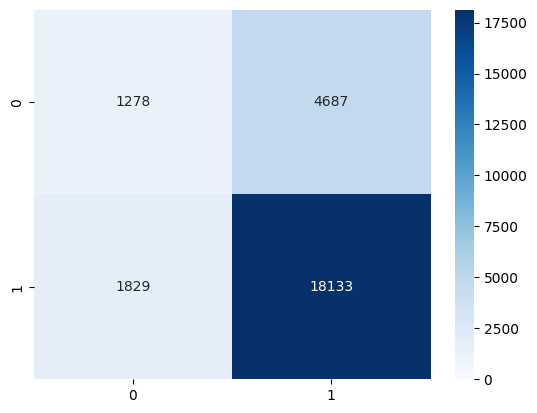

In [116]:
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True,
    vmin=0,
    cmap="Blues",
    fmt="d")

(0.0, 1.0)

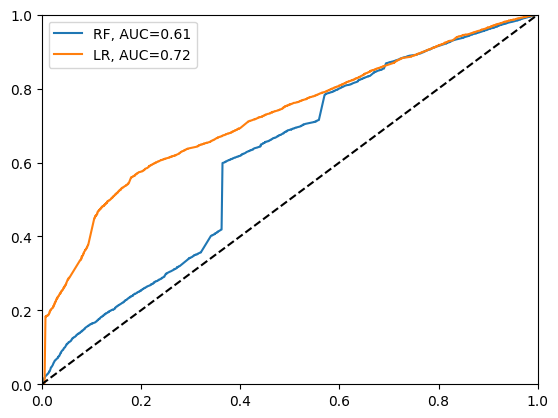

In [118]:
rf_fpr, rf_tpr, rf_thresholds = metrics.roc_curve(y_test, rf.predict_proba(x_test)[:, 1])
lr_fpr, lr_tpr, lr_thresholds = metrics.roc_curve(y_test, lr.predict_proba(x_test)[:, 1])

rf_roc_auc = metrics.auc(rf_fpr, rf_tpr)
lr_roc_auc = metrics.auc(lr_fpr, lr_tpr)

plt.plot(rf_fpr, rf_tpr,label=f"RF, AUC={rf_roc_auc:.2f}")
plt.plot(lr_fpr, lr_tpr,label=f"LR, AUC={lr_roc_auc:.2f}")
plt.legend()

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)